# Cardiac Patient Monitoring System
## 04 — Supervised Learning: Baseline Model (Phase 4, Milestone M3)

Input: `data/processed/heart_disease_cleveland_stage2.csv`.

This notebook covers:
1. Define X (features) and y (target)
2. Stratified train/test split (`random_state=42`)
3. Minimal leakage-free preprocessing (imputation + encoding + scaling), fit on training data only
4. Baseline model: Logistic Regression
5. Train, predict, evaluate
6. Explain why this baseline was chosen and what it tells us

**Note on preprocessing:** a `ColumnTransformer` is used here (not just for Phase 6) because a
baseline classifier cannot be fit on raw mixed-type data with missing values. All imputers/encoders/
scalers are fit **only on the training split**, per the project's data-leakage rule. Phase 6 will
extend this same mechanism with engineered features and formalize it as the final reusable
pipeline.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

RANDOM_STATE = 42

df = pd.read_csv("../data/processed/heart_disease_cleveland_stage2.csv")

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target_col = 'target'

df.shape


(303, 15)

## 1. Define X and y


In [2]:
X = df[numerical_features + categorical_features].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
y.value_counts(normalize=True).round(3)


X shape: (303, 13)
y shape: (303,)


target
0    0.541
1    0.459
Name: proportion, dtype: float64

## 2. Train/test split (stratified, reproducible)

Stratifying on `y` keeps the ~54/46 class ratio consistent across train and test, matching the
target distribution documented in Phase 3.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (242, 13)  Test shape: (61, 13)
Train class balance:
 target
0    0.541
1    0.459
Name: proportion, dtype: float64
Test class balance:
 target
0    0.541
1    0.459
Name: proportion, dtype: float64


**Interpretation:** An 80/20 split gives 242 training and 61 test observations — small but
workable given the dataset size (303 total). Stratification confirms both splits preserve the
original ~54/46 class proportions, so test-set performance won't be distorted by an accidental
imbalance shift.


## 3. Preprocessing (leakage-free)

- Numerical features: median imputation (none actually missing here, kept for robustness) +
  standard scaling (Logistic Regression is scale-sensitive).
- Categorical features: `ca` (median impute, passthrough numeric) and `thal` (most-frequent
  impute, one-hot encode) per the Phase 2 documented strategy; remaining categorical features
  one-hot encoded (`sex`/`fbs`/`exang` are already binary and one-hot encoding them is a no-op
  beyond a redundant column, kept for pipeline consistency).

All transformers are fit with `.fit()` only on `X_train`, then applied to `X_test` with
`.transform()` — never fit on test data.


In [4]:
onehot_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
passthrough_numeric_categorical = ['ca']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    ('cat_onehot', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), onehot_features),
    ('cat_num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), passthrough_numeric_categorical),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## 4. Baseline model: Logistic Regression

**Why Logistic Regression as the baseline:**
- It is the simplest, most interpretable classifier covered in the curriculum, and a standard
  choice for a binary medical-style classification baseline.
- It gives a clean reference point: any more complex model (Phase 5) must justify itself by
  beating this baseline, not merely by being more sophisticated.
- Its coefficients are directly interpretable (direction and rough magnitude of each feature's
  association with disease presence), which supports the EDA findings from Phase 3.


In [5]:
baseline_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

baseline_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','trestbps','chol',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all rema

## 5. Predict on the test set


In [6]:
y_pred = baseline_pipeline.predict(X_test)
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred, 'proba_presence': y_proba.round(3)}).head(10)


,y_true,y_pred,proba_presence
0,0,0,0.217
1,0,1,0.581
2,0,0,0.024
3,0,0,0.037
4,0,0,0.334
5,0,0,0.015
6,0,0,0.168
7,0,0,0.240
8,1,1,0.753
9,0,0,0.371


## 6. Initial evaluation


In [7]:
baseline_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba),
}
pd.Series(baseline_metrics).round(4)


accuracy     0.8689
precision    0.8125
recall       0.9286
f1           0.8667
roc_auc      0.9578
dtype: float64

In [8]:
print(classification_report(y_test, y_pred, target_names=['Absence', 'Presence']))


              precision    recall  f1-score   support

     Absence       0.93      0.82      0.87        33
    Presence       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



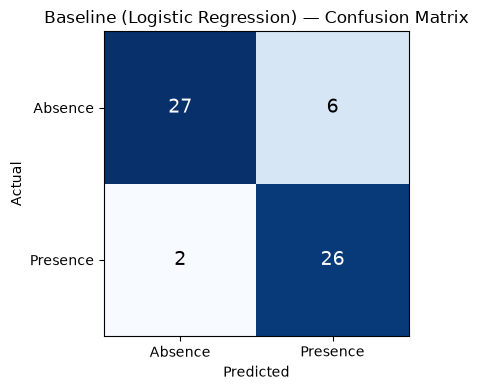

In [9]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Absence', 'Presence'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Absence', 'Presence'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Baseline (Logistic Regression) — Confusion Matrix')
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix/baseline_logistic_regression_cm.png", dpi=120, bbox_inches='tight')
plt.show()


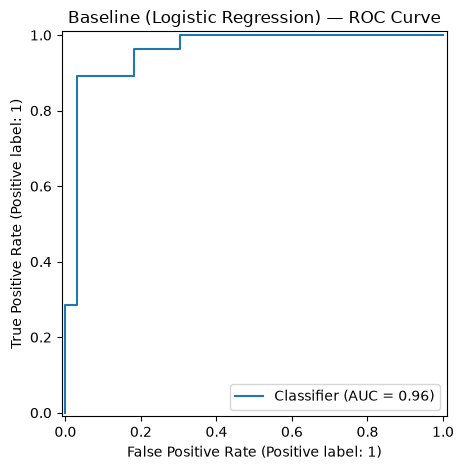

In [10]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Baseline (Logistic Regression) — ROC Curve")
plt.tight_layout()
plt.savefig("../outputs/figures/08_baseline_roc_curve.png", dpi=120, bbox_inches='tight')
plt.show()


## 7. Explain the baseline

- **Role as a baseline:** Logistic Regression establishes the minimum bar any more complex model
  must clear. If a fancier model in Phase 5 doesn't beat these numbers by a meaningful margin, the
  added complexity isn't justified.
- **What the confusion matrix says:** false negatives (actual presence predicted as absence) are
  the cell we care about most, since a missed cardiac risk is more dangerous than a false alarm
  (false positive, which mainly costs a follow-up test). Recall is watched closely for this reason.
- **What the initial numbers indicate:** on a near-balanced, well-behaved (post-cleaning) small
  dataset, a linear model already captures a large share of the signal, echoing the strong,
  fairly linear-looking associations found in Phase 3 EDA (`thalach`, `oldpeak`, `cp`, `thal`,
  `exang`). This sets a realistic ceiling expectation for Phase 5's comparison model — meaningful
  improvement is possible, but this is not a "broken" baseline to easily beat.

Baseline metrics are saved below for the Phase 5 comparison table.


In [11]:
import json
with open("../outputs/results/phase4_baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print("Saved baseline metrics.")


Saved baseline metrics.


## Phase 4 Quality Gate — Checklist

- [x] X and y defined
- [x] Stratified train/test split, reproducible (`random_state=42`)
- [x] Leakage-free preprocessing (fit on train only)
- [x] Baseline model (Logistic Regression) trained
- [x] Predictions generated on test set
- [x] Initial metrics recorded (accuracy, precision, recall, F1, ROC-AUC)
- [x] Confusion matrix produced and saved
- [x] Baseline choice and results explained
- [x] Metrics saved to `outputs/results/phase4_baseline_metrics.json` for later comparison

**Next:** Phase 5 — Second Classifier + Cross-Validation + Model Comparison (Milestone M4).
